In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [28]:
import numpy as np   
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import seaborn as sns 

DATA_DIR = "/kaggle/input/competitions/house-prices-advanced-regression-techniques"

def load():
    train = pd.read_csv(f"{DATA_DIR}/train.csv")
    test = pd.read_csv(f"{DATA_DIR}/test.csv")

    # outliers
    train = train.drop(
        train[(train.GrLivArea > 4000) & (train.SalePrice < 300000)].index
    )

    y = np.log1p(train.SalePrice)          # учим на log — метрика = RMSE(log)
    X = train.drop(columns=["Id", "SalePrice"])
    X_test = test.drop(columns=["Id"])
    return X, y, X_test, test["Id"]

# NA = «объекта нет» - строка "None"
NONE_CAT = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
# NA = «объекта нет» - число 0
NONE_NUM = [
    "GarageArea", "GarageCars", "GarageYrBlt", "MasVnrArea",
    "TotalBsmtSF", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "BsmtFullBath", "BsmtHalfBath",
]
# Порядковые качества
QUAL_MAP = {"None": 0, 
            "Po": 1, 
            "Fa": 2, 
            "TA": 3, 
            "Gd": 4, 
            "Ex": 5}

QUAL_COLS = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
]

# По смыслу категориальные, хоть и числа
AS_STR = ["MSSubClass", "MoSold", "YrSold"]


def domain_preprocess(X):
    X = X.copy()
    X[NONE_CAT] = X[NONE_CAT].fillna("None")
    X[NONE_NUM] = X[NONE_NUM].fillna(0)

    for c in QUAL_COLS:
        X[c] = X[c].map(QUAL_MAP)

    # LotFrontage: медиана(группировка по району)
    X["LotFrontage"] = X.groupby("Neighborhood")["LotFrontage"].transform(
        lambda s: s.fillna(s.median())
    )

    for c in AS_STR:
        X[c] = X[c].astype(str)

    X["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]
    X["TotalBath"] = (X["FullBath"] + 0.5 * X["HalfBath"]
                      + X["BsmtFullBath"] + 0.5 * X["BsmtHalfBath"])
    X["HouseAge"] = X["YrSold"].astype(int) - X["YearBuilt"]
    X["HasPool"] = (X["PoolArea"] > 0).astype(int)
    X["Has2ndFloor"] = (X["2ndFlrSF"] > 0).astype(int)
    X["IsRemodeled"] = (X["YearRemodAdd"] != X["YearBuilt"]).astype(int)

    return X

# Ridge Regression

In [29]:
def build_pipeline(X: pd.DataFrame, model=None, skew_threshold=0.75) -> Pipeline:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    
    skewness = X[num_cols].skew()
    skewed_cols = [
        c for c in skewness[skewness > skew_threshold].index if X[c].min() >= 0
    ]
    plain_cols = [c for c in num_cols if c not in skewed_cols]

    skewed_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p)),
        ("scale", StandardScaler()),
    ])
    plain_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")), 
        ("scale", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),  
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer([
        ("num_skewed", skewed_pipe, skewed_cols),
        ("num_plain", plain_pipe, plain_cols),
        ("cat", cat_pipe, cat_cols),
    ])

    if model is None:
        model = Ridge(alpha=10.0)
    return Pipeline([
        ("pre", pre), 
        ("model", model)])


def cv_rmse_Ridge(pipe, X, y, folds=5):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    neg_mse = cross_val_score(pipe, X, y, scoring="neg_mean_squared_error", cv=kf)
    return np.sqrt(-neg_mse)

In [30]:
X, y, X_test, test_id = load()

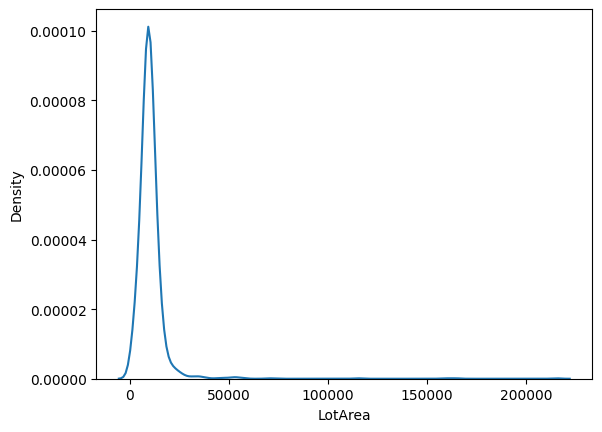

<Axes: xlabel='LotArea', ylabel='Density'>

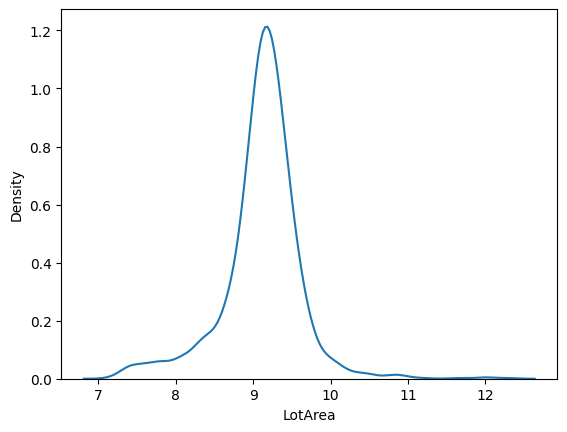

In [31]:
sns.kdeplot(X["LotArea"])
plt.show()
sns.kdeplot(np.log1p(X["LotArea"]))

In [32]:
X = domain_preprocess(X)
pipe = build_pipeline(X)
scores = cv_rmse_Ridge(pipe, X, y, folds=5)
print(f"CV RMSE(log): {scores.mean():.4f} +/- {scores.std():.4f}")

CV RMSE(log): 0.1133 +/- 0.0074


# CatBoostRegressor

In [33]:
def build_catboost(**params):
    default_params = dict(
        loss_function="RMSE",
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3.0,
        random_seed=42,
        verbose=False,
    )
    default_params.update(params)
    return CatBoostRegressor(**default_params)


def cv_rmse_CB(model, X, y, cat_idx, folds=5):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    neg_mse = cross_val_score(
        model, X, y, scoring="neg_mean_squared_error", cv=kf,
        params={"cat_features": cat_idx},
    )
    return np.sqrt(-neg_mse)

In [35]:
X, y, X_test, test_id = load()
X = domain_preprocess(X)

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
cat_idx = [X.columns.get_loc(c) for c in cat_cols]
X[cat_cols] = X[cat_cols].fillna("Missing")

model = build_catboost()
scores = cv_rmse_CB(model, X, y, cat_idx, folds=5)
print(f"CatBoost CV RMSE(log): {scores.mean():.4f} +/- {scores.std():.4f}")

CatBoost CV RMSE(log): 0.1152 +/- 0.0078


In [38]:
X_test = domain_preprocess(X_test)
X_test[cat_cols] = X_test[cat_cols].fillna("Missing")
model.fit(X, y, cat_features=cat_idx)
pred = np.expm1(model.predict(X_test))
sub = pd.DataFrame({"Id": test_id, "SalePrice": pred})
sub.to_csv("submission_catboost.csv", index=False)

In [ ]:
'''
X_test = domain_preprocess(X_test)
pipe.fit(X, y)
pred = np.expm1(pipe.predict(X_test))
sub = pd.DataFrame({"Id": test_id, "SalePrice": pred})
sub.to_csv("submission.csv", index=False)
'''